# Haoyu-Style Real-Space Chern Marker Comparison

This notebook constructs the exact equilibrium ground-state two-point matrix of the two-band Chern-insulator Hamiltonian used by `classA_U1FGTN`, then compares:

- a Python equivalent of Haoyu's full real-space marker in `realspace_marker_check.jl`,
- this repo's `classA_U1FGTN.local_chern_marker_flat(..., apply_tanh=False)` definition.

The comparison uses the same occupied-state projector for both definitions.

In [8]:
# Project bootstrap
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

ROOT, SRC

(PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit'),
 PosixPath('/home/abhuiyan/class_A_fermionic_adaptive_circuit/src'))

In [9]:
import importlib

import numpy as np
import matplotlib.pyplot as plt

classA_module = importlib.import_module("fgtn.classA_U1FGTN")
importlib.reload(classA_module)
from fgtn.classA_U1FGTN import classA_U1FGTN

np.set_printoptions(precision=6, suppress=True)

## Marker Implementations

Haoyu's full real-space method uses `PXP = C X C`, `PYP = C Y C`, and `real(-2π i diag([PXP, PYP]))`, summed over the two local orbitals. The native `classA_U1FGTN` covariance convention for an occupied projector `C` is `G = 2 C.conj() - I`; its marker uses `+2π i`, so the native classA marker is the negative of Haoyu's raw marker for the same `C`. The last diagnostic cell also feeds `G = 2C - I` to show that the remaining difference is exactly this conjugation/sign convention.

In [21]:
def idx(mu, x, y, Nx):
    """Flattening used in classA_U1FGTN: mu + 2*x + 2*Nx*y."""
    return int(mu + 2 * x + 2 * Nx * y)


def occupied_projector_from_hamiltonian(H, tol=1e-10):
    """Exact zero-temperature two-point matrix C from occupied single-particle states."""
    evals, evecs = np.linalg.eigh(np.asarray(H, dtype=np.complex128))
    occ = evals < -tol
    if not np.any(occ):
        # Fallback for exactly flat or numerically shifted spectra: half filling.
        order = np.argsort(evals)
        occ = np.zeros_like(evals, dtype=bool)
        occ[order[: H.shape[0] // 2]] = True
    C = evecs[:, occ] @ evecs[:, occ].conj().T
    C = 0.5 * (C + C.conj().T)
    return C, evals, occ


def haoyu_realspace_chern_marker(C, Nx, Ny, coord_origin=0):
    """Python equivalent of Haoyu's realspace_marker_map(Cfull, row_ids, Lx).

    Returns an (Nx, Ny) map. For an exact projector, shifting coordinate origin
    only changes X/Y by constants and leaves the commutator marker unchanged.
    """
    C = np.asarray(C, dtype=np.complex128)
    dim = 2 * Nx * Ny
    if C.shape != (dim, dim):
        raise ValueError(f"Expected C shape {(dim, dim)}, got {C.shape}")

    xvec = np.zeros(dim, dtype=float)
    yvec = np.zeros(dim, dtype=float)
    for x in range(Nx):
        for y in range(Ny):
            block = [idx(mu, x, y, Nx) for mu in (0, 1)]
            xvec[block] = x + coord_origin
            yvec[block] = y + coord_origin

    PXP = (C * xvec[None, :]) @ C
    PYP = (C * yvec[None, :]) @ C
    comm = PXP @ PYP - PYP @ PXP
    local_basis = np.real((-2.0 * np.pi * 1j) * np.diag(comm))

    cmap = np.zeros((Nx, Ny), dtype=float)
    for x in range(Nx):
        for y in range(Ny):
            cmap[x, y] = sum(local_basis[idx(mu, x, y, Nx)] for mu in (0, 1))
    return cmap


def classA_marker_native_from_two_point(model, C):
    """Evaluate local_chern_marker_flat with the native classA covariance convention."""
    dim = C.shape[0]
    G_for_classA = 2.0 * C.conj() - np.eye(dim, dtype=np.complex128)
    return model.local_chern_marker_flat(G_for_classA, apply_tanh=False)


def classA_marker_conjugated_input(model, C):
    """Diagnostic input convention that makes classA's internal P equal C.conj()."""
    dim = C.shape[0]
    G_for_classA = 2.0 * C - np.eye(dim, dtype=np.complex128)
    return model.local_chern_marker_flat(G_for_classA, apply_tanh=False)


def summarize_map(name, arr):
    arr = np.asarray(arr, dtype=float)
    print(
        f"{name:>18s}: sum={arr.sum(): .12f}, mean={arr.mean(): .12f}, "
        f"min={arr.min(): .12f}, max={arr.max(): .12f}"
    )

## Exact Equilibrium Chern-Insulator Ground State

The Hamiltonian below is built from `classA_U1FGTN._domain_wall_hamiltonian(...)` with a uniform mass profile and periodic boundaries. Diagonalizing it gives the occupied-state projector `C = V_occ V_occ†`.

In [22]:
# Parameters
Nx = 18
Ny = 18
alpha = 1.0      # 0 < alpha < 2 is the topological regime for this convention
periodic = True    # open boundaries give a clean local-marker bulk plateau

model = classA_U1FGTN(Nx=Nx, Ny=Ny, DW=False, nshell=1, alpha_1=alpha)
alpha_profile = alpha * np.ones((Nx, Ny), dtype=np.complex128)
H = model._domain_wall_hamiltonian(periodic=periodic, alpha=alpha_profile)
C, evals, occ = occupied_projector_from_hamiltonian(H)

print(f"H shape: {H.shape}")
print(f"occupied states: {occ.sum()} / {len(occ)}")
print(f"single-particle gap around zero: {evals[occ.size // 2] - evals[occ.size // 2 - 1]:.12g}")
print(f"projector Hermiticity error: {np.linalg.norm(C - C.conj().T, ord=np.inf):.3e}")
print(f"projector idempotency error: {np.linalg.norm(C @ C - C, ord=np.inf):.3e}")

------------------------- classA_U1FGTN Initialized -------------------------
H shape: (648, 648)
occupied states: 324 / 648
single-particle gap around zero: 2
projector Hermiticity error: 0.000e+00
projector idempotency error: 4.525e-14


In [23]:
C_haoyu = haoyu_realspace_chern_marker(C, Nx, Ny, coord_origin=0)
C_classA_native = classA_marker_native_from_two_point(model, C)
C_classA_conjugated = classA_marker_conjugated_input(model, C)

# Optional: compare to classA's direct k-space construction when the Hamiltonian is periodic.
C_classA_direct = None
if periodic:
    G_classA_direct = model.G_CI(alpha=alpha)
    C_classA_direct = model.local_chern_marker_flat(G_classA_direct, apply_tanh=False)

summarize_map("Haoyu-style", C_haoyu)
summarize_map("classA native", C_classA_native)
summarize_map("classA conj input", C_classA_conjugated)
if C_classA_direct is not None:
    summarize_map("classA G_CI", C_classA_direct)
print()
print("max |Haoyu + classA native| =", np.max(np.abs(C_haoyu + C_classA_native)))
print("max |Haoyu - classA conjugated input| =", np.max(np.abs(C_haoyu - C_classA_conjugated)))
if C_classA_direct is not None:
    print("max |classA native - classA G_CI| =", np.max(np.abs(C_classA_native - C_classA_direct)))

       Haoyu-style: sum=-0.000000000000, mean=-0.000000000000, min=-58.521198302554, max= 7.648525556922
     classA native: sum=-0.000000000000, mean=-0.000000000000, min=-7.648525556922, max= 58.521198302554
 classA conj input: sum= 0.000000000000, mean= 0.000000000000, min=-58.521198302554, max= 7.648525556922
       classA G_CI: sum= 0.000000000000, mean= 0.000000000000, min=-7.648525556922, max= 58.521198302554

max |Haoyu + classA native| = 7.815970093361102e-14
max |Haoyu - classA conjugated input| = 7.815970093361102e-14
max |classA native - classA G_CI| = 5.3290705182007514e-14


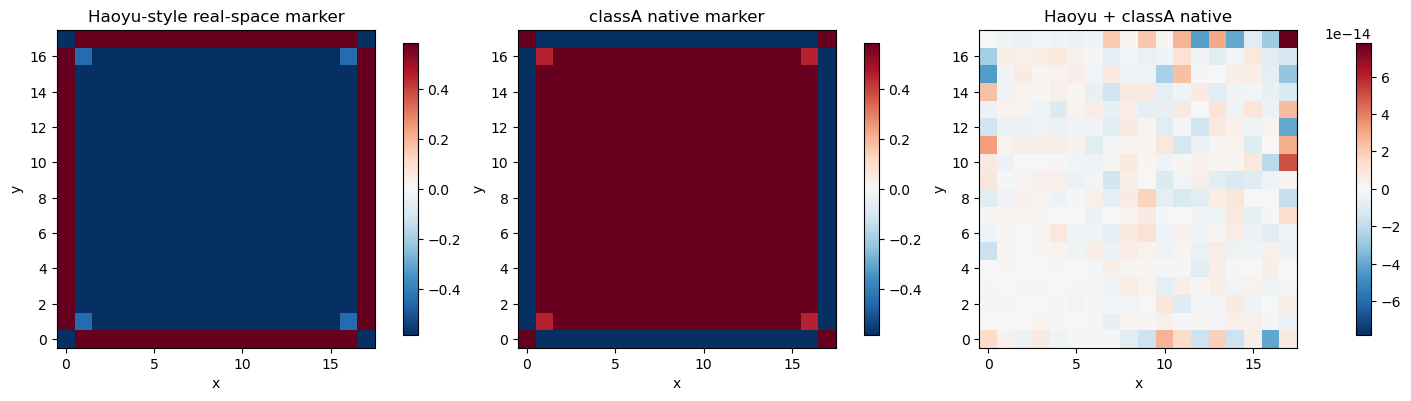

In [26]:
vmax = max(np.max(np.abs(C_haoyu)), np.max(np.abs(C_classA_native)))/100
diff = C_haoyu + C_classA_native
diff_vmax = max(np.max(np.abs(diff)), 1e-15)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

im0 = axes[0].imshow(C_haoyu.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title("Haoyu-style real-space marker")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(C_classA_native.T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("classA native marker")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff.T, origin="lower", cmap="RdBu_r", vmin=-diff_vmax, vmax=diff_vmax)
axes[2].set_title("Haoyu + classA native")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

## Convention Check

The cell below isolates the convention difference. With native classA input `G = 2C.conj() - I`, the raw marker is the negative of Haoyu's `-2πi` convention. With diagnostic input `G = 2C - I`, classA's internal conjugation flips the projector and matches Haoyu's raw map.

In [14]:
print("native classA input:      max |Haoyu + classA| =", np.max(np.abs(C_haoyu + C_classA_native)))
print("diagnostic conjugated input: max |Haoyu - classA| =", np.max(np.abs(C_haoyu - C_classA_conjugated)))

native classA input:      max |Haoyu + classA| = 7.815970093361102e-14
diagnostic conjugated input: max |Haoyu - classA| = 7.815970093361102e-14
